# Tutorial 5:  Corss-disease states denoising and integration of STARmap PLUS datasets for AD

In this tutorial, we apply STADIM to an in situ sequencing dataset generated by STARmap PLUS, derived from a mouse model of Alzheimer’s disease (AD). This dataset includes detailed cell-type annotations as well as the spatial locations of amyloid plaque cores in the disease slices S5-S8.  
We download the data and information of amyloid plaque cores under study SCP1375 https://singlecell.broadinstitute.org/single_cell/study/SCP1375.

## Quick view data

/home/xiaost/anaconda3/envs/stadim/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


S1
AnnData object with n_obs × n_vars = 9803 × 2766
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'sex', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'orig_index', 'batch', 'time', 'group', 'replicate', 'label', 'region', 'region_merged', 'top_level_cell_type', 'sub_level_cell_type', 'sample'
    obsm: 'spatial'
S2
AnnData object with n_obs × n_vars = 8506 × 2766
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'sex', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'orig_index', 'batch', 'time', 'group', 'replicate', 'label', 'region', 'region_merged', 'top_level_cell_type', 'sub_level_cell_type', 'sample'
    obsm: 'spatial'
S3
AnnData object with n_obs × n_vars = 9428 × 2766
    obs: 'biosample_id', 'donor_id', 'species', 

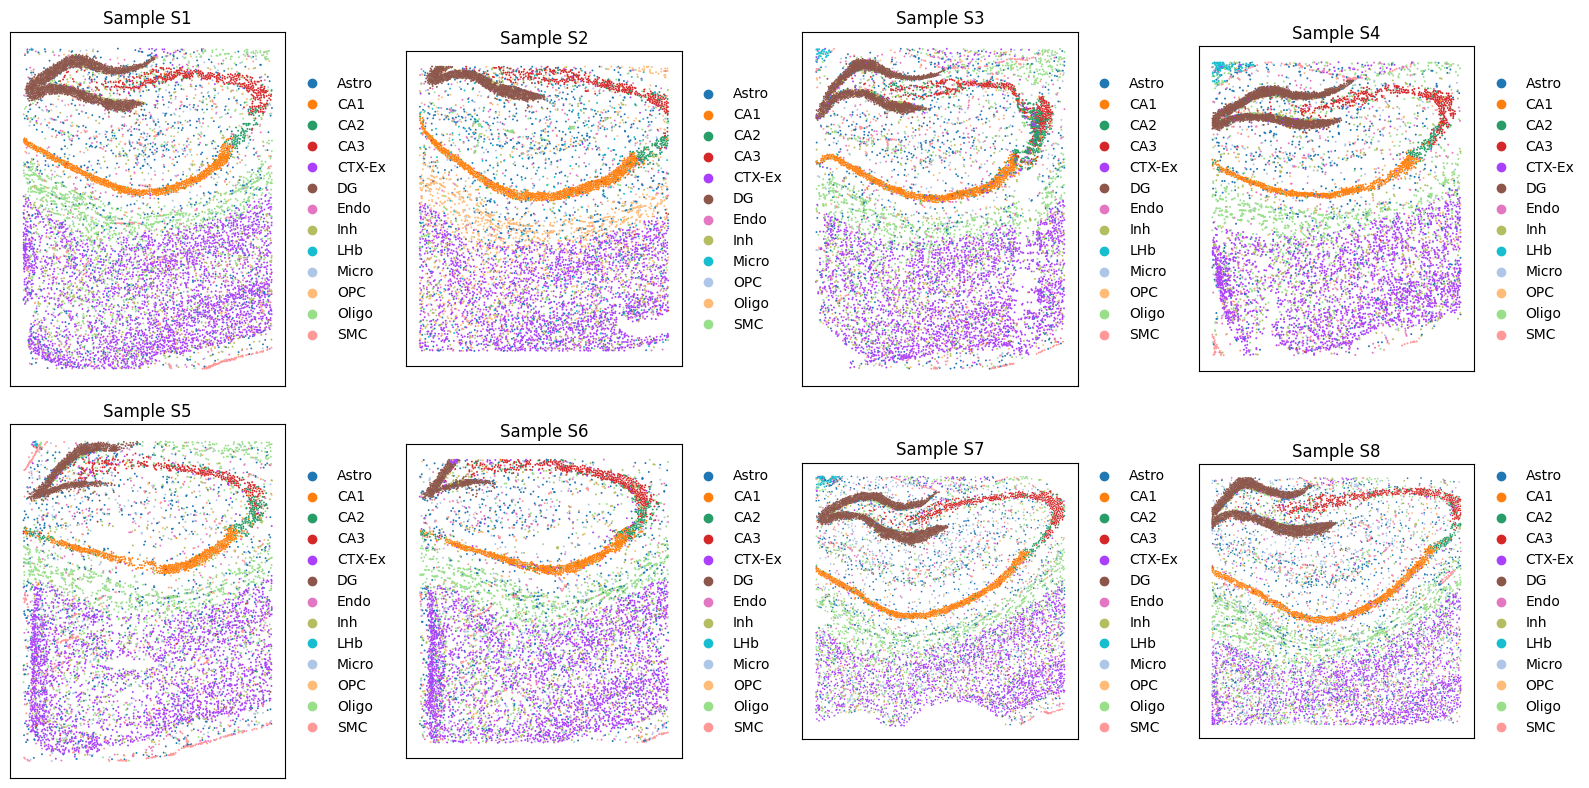

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import os

sample_ids = [f'S{i}' for i in range(1, 9)]
data_dir = '/data2/xiaost/SODA/Data/MB_SCP1375/'

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten() 

for i, s_id in enumerate(sample_ids):
    adata = sc.read_h5ad(os.path.join(data_dir, f'{s_id}.h5ad'))
    print(f'{s_id}')
    print(adata)
    sc.pl.spatial(adata, color='top_level_cell_type', ax=axes[i], show=False, title=f'Sample {s_id}', spot_size=150)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## Run STADIM

**Note: For the high-resolution dataset, we added filtering criteria to the cells and selected more candidate neighbors during the triplet construction phase.**

You can call the STADIM command directly in your terminal:
```bash
nohup stadim --input "./S"{1,2,3,4,5,6,7,8}".h5ad" --save_preprocessed_h5ad None --save_dir ./MB_SCP1375_test --device "cuda:0" --monitor --seed 2026 --min_genes 10 --min_cells 10 --knn_c 30 --knn_e 70 --mnn_n 100 > ./MB_SCP1375_test.log 2>&1 &
```
and load the results into your Python environment for downstream analysis. The denoised expression matrix is conveniently stored within the `layers` attribute:
```python
import anndata as ad

adata = ad.read_h5ad('/MB_SCP1375_test/sdata.h5ad')

## The denoised gene expressionis is stored in adata.layers['STADIM']
print(adata)
```
or you can call STADIM within a Jupyter Notebook as follows:

In [2]:
import stadim

adata = stadim.run_STADIM(['/data2/xiaost/SODA/Data/MB_SCP1375/S1.h5ad', '/data2/xiaost/SODA/Data/MB_SCP1375/S2.h5ad',
                          '/data2/xiaost/SODA/Data/MB_SCP1375/S3.h5ad', '/data2/xiaost/SODA/Data/MB_SCP1375/S4.h5ad',
                          '/data2/xiaost/SODA/Data/MB_SCP1375/S5.h5ad', '/data2/xiaost/SODA/Data/MB_SCP1375/S6.h5ad',
                          '/data2/xiaost/SODA/Data/MB_SCP1375/S7.h5ad', '/data2/xiaost/SODA/Data/MB_SCP1375/S8.h5ad'], 
                          save_preprocessed_h5ad=None, save_dir=None, 
                          sample_names=None, batch_key='sample', device='cuda:5', seed=2026, 
                          min_genes=10, min_cells=10, nhvgs=2000, dim=50, knn_c=30, knn_e=70, mnn_n=100,
                          batch_size=256, triplets_update_ratio=0.8, hard_triplets_ratio=0.7,
                          epochs=100, lr=1e-3, loss_mode='nb', beta_trip=0.1,
                          encoder_layers=[512, 256, 64], decoder_layers=[1000])

Results will be stored in adata.layers['STADIM']

=== 1. Begin read_data!
Detected multi-slice data, total 8 slices
  Slice 1: Using user-defined column 'sample' as sample
  Slice 1: Keeping existing sample label S1
  Slice 2: Using user-defined column 'sample' as sample
  Slice 2: Keeping existing sample label S2
  Slice 3: Using user-defined column 'sample' as sample
  Slice 3: Keeping existing sample label S3
  Slice 4: Using user-defined column 'sample' as sample
  Slice 4: Keeping existing sample label S4
  Slice 5: Using user-defined column 'sample' as sample
  Slice 5: Keeping existing sample label S5
  Slice 6: Using user-defined column 'sample' as sample
  Slice 6: Keeping existing sample label S6
  Slice 7: Using user-defined column 'sample' as sample
  Slice 7: Keeping existing sample label S7
  Slice 8: Using user-defined column 'sample' as sample
  Slice 8: Keeping existing sample label S8

Merging data...

Raw Merged Data: 72165 spots × 2766 genes
Unified Filtering (min_g

Preparing triplet: 100%|██████████| 72165/72165 [00:17<00:00, 4045.07it/s]



=== 5. Begin IterableTripletDataset!
Initializing triplets...
IterableTripletDataset Initialized: 72165 anchors, batch_size=256

=== 6. Begin calculate_recommended_margin!
Calculating recommended margin (averaging over 5 runs)...

Margins from 5 runs: [4.0721, 4.0501, 4.0252, 3.9645, 3.9303]
Final Recommended Margin: 4.0084

=== 7. Starting training...
Begin training: device=cuda:5


Training: 100%|██████████| 100/100 [14:33<00:00,  8.73s/it, recon=0.175, triplet=0.351, total=0.210]



=== 8. Generating denoised expression...
   Data size (2.00e+08) is within limits. Allocating memory for denoised data.

All processes finished! Total time: 22.07 mins.


In [3]:
print(adata)

AnnData object with n_obs × n_vars = 72165 × 2766
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'sex', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'orig_index', 'batch', 'time', 'group', 'replicate', 'label', 'region', 'region_merged', 'top_level_cell_type', 'sub_level_cell_type', 'sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'top_hvgs'
    obsm: 'spatial', 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'STADIM'
    layers: 'X_raw', 'X_norm', 'X_log', 'STADIM', 'STADIM_withbatch'


## Analysis

In [4]:
import anndata as ad
import pandas as pd
import scanpy as sc 
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
plt.rcParams.update({
    'font.size': 16, 
    'axes.labelsize': 18,  
    'axes.titlesize': 18,  
    'xtick.labelsize': 16, 
    'ytick.labelsize': 16,  
    'legend.fontsize': 16,
})

styles = {
    'STADIM': {'color': '#d62728', 'marker': '*', 'ms': 10, 'lw': 2.5, 'zorder': 10},
    'X_norm': {'color': '#c7c7c7', 'marker': 'o', 'ms': 6, 'lw': 1.5, 'zorder': 5}
}

### Batch Entropy

In [5]:
%%time

res = stadim.calculate_batch_entropy(adata, test_layers=['X_norm', 'STADIM'], k_range=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 
                                     group_key='top_level_cell_type', donor_id='MB_SCP1375', batch_key='sample', n_hvg=2000)

batch_entropy = pd.DataFrame(res)

display(batch_entropy)

,Method,Donor_ID,K,Avg_Entropy,Avg_Region_Ratio
0,X_norm,MB_SCP1375,10,0.599390,0.756310
1,X_norm,MB_SCP1375,20,0.681480,0.747287
2,X_norm,MB_SCP1375,30,0.715242,0.741435
3,X_norm,MB_SCP1375,40,0.734649,0.736935
4,X_norm,MB_SCP1375,50,0.747662,0.733296
5,X_norm,MB_SCP1375,60,0.757433,0.730088
6,X_norm,MB_SCP1375,70,0.764947,0.727324
7,X_norm,MB_SCP1375,80,0.771243,0.724833
8,X_norm,MB_SCP1375,90,0.776517,0.722585
9,X_norm,MB_SCP1375,100,0.781012,0.720530


CPU times: user 21min 28s, sys: 31.1 s, total: 21min 59s
Wall time: 5min 30s


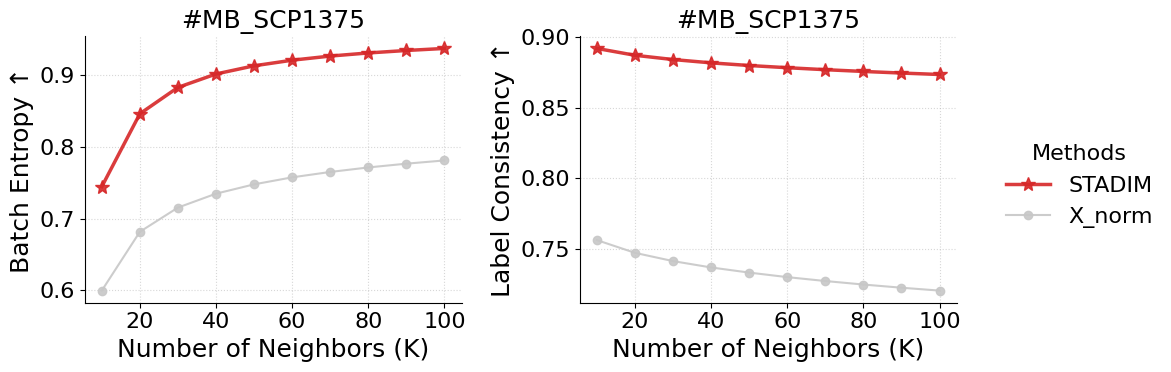

In [6]:
metrics = ['Avg_Entropy', 'Avg_Region_Ratio']
y_labels = ['Batch Entropy \u2191', 'Label Consistency \u2191']

plot_data = batch_entropy.groupby(['Method', 'K'])[metrics].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

for i, metric in enumerate(metrics):
    ax = axes[i]
    for m in ['STADIM','X_norm']:
        data = plot_data[plot_data['Method'] == m].sort_values('K')
        if data.empty: continue
        
        ax.plot(data['K'], data[metric], label=m, 
                color=styles[m]['color'], marker=styles[m]['marker'],
                markersize=styles[m]['ms'], linewidth=styles[m]['lw'], 
                zorder=styles[m]['zorder'], alpha=0.9)

    ax.set_title(f"#MB_SCP1375")
    ax.set_xlabel('Number of Neighbors (K)')
    ax.set_ylabel(y_labels[i])
    ax.set_xticks([20, 40, 60, 80, 100])
    ax.grid(True, linestyle=':', alpha=0.5)
    sns.despine(ax=ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), 
           title='Methods', frameon=False)

plt.tight_layout()
plt.show()

### weighted Coefficient of Variation (wCV)

In [7]:
benchmark_adata = stadim.create_shuffled_batches(adata, n_batches=5)
benchmark_adata.var = adata.var
print(f"\nbenchmark adata: {benchmark_adata}")


benchmark adata: AnnData object with n_obs × n_vars = 72165 × 2766
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'sex', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'orig_index', 'batch', 'time', 'group', 'replicate', 'label', 'region', 'region_merged', 'top_level_cell_type', 'sub_level_cell_type', 'sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor', 'sim_batch'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    obsm: 'spatial', 'S_scale', 'X_hvg_scale', 'X_pca', 'STADIM'
    layers: 'X_raw', 'X_norm', 'X_log', 'STADIM', 'STADIM_withbatch'


In [8]:
%%time

wcv = {}
for gene_type in ["HVGs", "LVGs"]:
    print(f"\ngene_type: {gene_type}")
    
    # wCV before and after STADIM 
    res_deno = stadim.calculate_cv(adata, batch_key='sample', label_key='top_level_cell_type', methods=['X_norm', 'STADIM'], gene_type=gene_type)
    
    # wCV of simulated benchmark no batch data, calculated with X_norm and shuffled labels
    res_bench = stadim.calculate_cv(benchmark_adata, batch_key='sim_batch', label_key='top_level_cell_type', methods=['X_norm'], gene_type=gene_type)
    res_bench = res_bench.rename(columns={'X_norm': 'Sim_NoBatch'})

    wcv[gene_type] = res_bench.join(res_deno, how='inner')

print(wcv["HVGs"].head())


gene_type: HVGs
--- Calculating CV on 2000 genes of type: HVGs ---
Methods successfully calculated: ['X_norm', 'STADIM']
--- Calculating CV on 2000 genes of type: HVGs ---
Methods successfully calculated: ['X_norm']

gene_type: LVGs
--- Calculating CV on 766 genes of type: LVGs ---
Methods successfully calculated: ['X_norm', 'STADIM']
--- Calculating CV on 766 genes of type: LVGs ---
Methods successfully calculated: ['X_norm']
         Sim_NoBatch    X_norm    STADIM
A2m         0.146133  0.296734  0.103721
Aak1        0.189289  0.339597  0.105297
Abca7       0.150978  0.284041  0.099893
Abcc9       0.203739  0.373357  0.148119
Abhd17a     0.232470  0.408655  0.161237
CPU times: user 6.62 s, sys: 3.46 s, total: 10.1 s
Wall time: 10.1 s


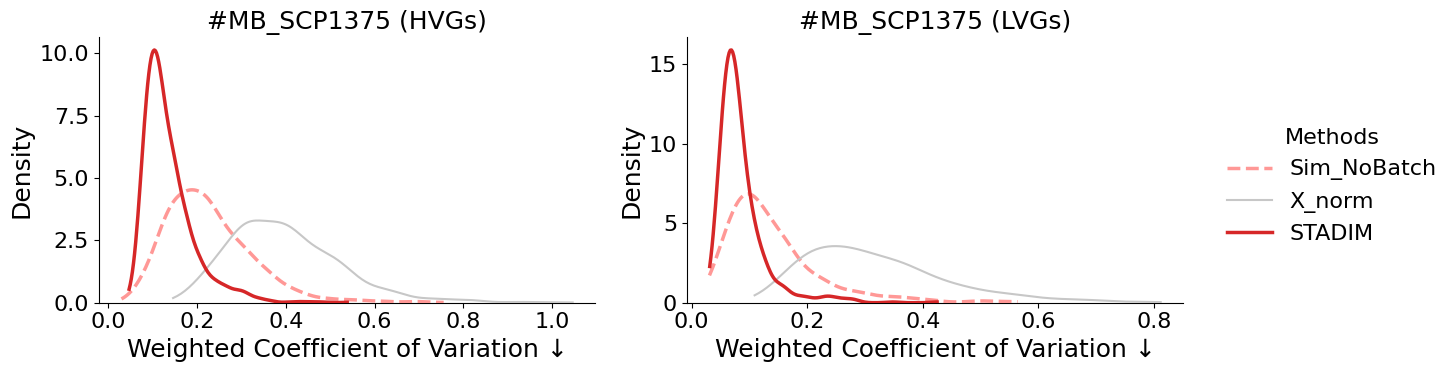

In [9]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

methods = ['Sim_NoBatch', 'X_norm', 'STADIM']
colors = {'Sim_NoBatch': '#ff9896', 'X_norm': '#c7c7c7', 'STADIM': '#d62728'}
gene_types = ['HVGs', 'LVGs']


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, g_type in enumerate(gene_types):
    ax = axes[i]
    df = wcv[g_type]
        
    for m in methods:
        if m not in df.columns: continue

        style = {
            'label': m, 'color': colors.get(m, '#333333'), 'fill': False,
            'linewidth': 2.5 if m != 'X_norm' else 1.5,
            'linestyle': '--' if m == 'Sim_NoBatch' else '-',
            'zorder': 10 if m == 'STADIM' else 5,
            'cut': 0
        }
        
        sns.kdeplot(df[m].dropna(), ax=ax, **style)

    ax.set_title(f"#MB_SCP1375 ({g_type})")
    ax.set_xlabel("Weighted Coefficient of Variation \u2193")
    sns.despine(ax=ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), 
           title='Methods', frameon=False)

plt.tight_layout()
plt.show()

### Latent representation Umap

In [10]:
%%time

sc.pp.neighbors(adata, use_rep='STADIM', key_added=f'neighbors_STADIM')
sc.tl.umap(adata, neighbors_key=f'neighbors_STADIM')
adata.obsm['X_umap_STADIM'] = adata.obsm['X_umap'].copy()
print(adata)     

AnnData object with n_obs × n_vars = 72165 × 2766
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'sex', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'orig_index', 'batch', 'time', 'group', 'replicate', 'label', 'region', 'region_merged', 'top_level_cell_type', 'sub_level_cell_type', 'sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'top_hvgs', 'neighbors_STADIM', 'umap'
    obsm: 'spatial', 'S_scale', 'X_hvg_scale', 'X_pca', 'STADIM', 'X_umap', 'X_umap_STADIM'
    layers: 'X_raw', 'X_norm', 'X_log', 'STADIM', 'STADIM_withbatch'
    obsp: 'neighbors_STADIM_distances', 'neighbors_STADIM_connectivities'
CPU times:

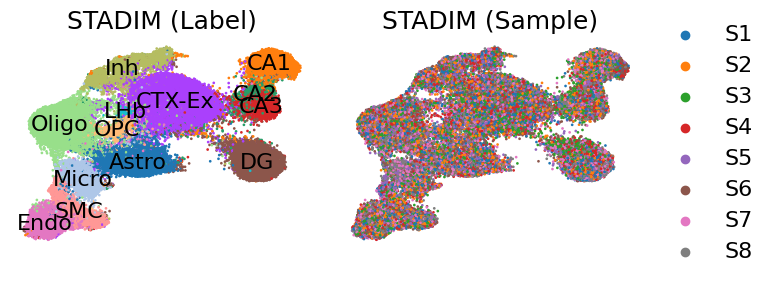

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sc.pl.embedding(adata, basis='X_umap_STADIM', color='top_level_cell_type', ax=axes[0], show=False, legend_loc='on data', legend_fontweight='normal',
                title='STADIM (Label)', frameon=False, s=15)

sc.pl.embedding(adata[np.random.permutation(adata.n_obs)], basis='X_umap_STADIM', color='sample', ax=axes[1], show=False, 
                title='STADIM (Sample)', frameon=False, s=15)

plt.tight_layout()
plt.show()

### Plaque-Induced Genes (PIGs) co-expression patterns

Calculate how far each cell is from the nearest Alzheimer's plaque.

WHAT THIS CODE DOES:
1. Load precise X/Y coordinates for all cells (S1-S8).
2. Load the location of plaques for disease samples (S5-S8).
3. Compute the distance between each cell and its closest plaque.

RESULT:
Each cell in the disease samples now has a 'min_dist_to_plaque' value, allowing us to study how proximity to plaques affects gene expression.

In [12]:
from scipy.spatial.distance import cdist

# 1. Initialize coordinate storage and plaque data container
adata.obsm['spatial_scaled'] = np.full((adata.n_obs, 2), np.nan)
plaque_dict = {}
all_samples = [f'S{i}' for i in range(1, 9)]
disease_samples = ['S5', 'S6', 'S7', 'S8']

# 2. Process all samples to align spatial coordinates
for s_id in all_samples:
    # Get the file label associated with the sample ID
    label = adata.obs[adata.obs['sample'] == s_id]['label'].unique()[0]
    
    # Load scaled spatial coordinates from CSV
    spatial_path = f'/data2/xiaost/SODA/Data/MB_SCP1375/data/spatial_{label}.csv'
    df_spatial = pd.read_csv(spatial_path, skiprows=[1])
    
    # Clean and set index with sample prefix to match adata.obs_names
    df_spatial['NAME'] = df_spatial['NAME'].astype(str).str.strip()
    df_spatial.index = f"{s_id}_" + df_spatial['NAME']
    
    # Align and fill coordinates into adata.obsm
    mask = adata.obs['sample'] == s_id
    current_obs_names = adata.obs_names[mask]
    aligned_data = df_spatial.reindex(current_obs_names)[['X-scaled', 'Y-scaled']]
    adata.obsm['spatial_scaled'][mask] = aligned_data.values.astype(float)
    
    # Load plaque data only for disease samples
    if s_id in disease_samples:
        plq_path = f'/data2/xiaost/SODA/Experiments/Fig6_MB_SCP1375/plaque/plaque_{label}.csv'
        plaque_dict[s_id] = pd.read_csv(plq_path)

# 3. Calculate distance from cells to nearest plaque for disease samples
adata.obs['min_dist_to_plaque'] = np.inf

for s_id in disease_samples:
    # Get cell coordinates for current sample
    sample_mask = adata.obs['sample'] == s_id
    cell_coords = adata.obsm['spatial_scaled'][sample_mask]
    
    # Get plaque center coordinates
    plaque_coords = plaque_dict[s_id][['m.cx', 'm.cy']].values
    
    # Compute Euclidean distance matrix (Cells x Plaques)
    dist_matrix = cdist(cell_coords, plaque_coords, metric='euclidean')
    
    # Store the distance to the closest plaque for each cell
    adata.obs.loc[sample_mask, 'min_dist_to_plaque'] = np.min(dist_matrix, axis=1)

print(adata)

AnnData object with n_obs × n_vars = 72165 × 2766
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'sex', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'orig_index', 'batch', 'time', 'group', 'replicate', 'label', 'region', 'region_merged', 'top_level_cell_type', 'sub_level_cell_type', 'sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor', 'min_dist_to_plaque'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'top_hvgs', 'neighbors_STADIM', 'umap', 'top_level_cell_type_colors'
    obsm: 'spatial', 'S_scale', 'X_hvg_scale', 'X_pca', 'STADIM', 'X_umap', 'X_umap_STADIM', 'spatial_scaled'
    layers: 'X_raw', 'X_norm', 'X_log', 'STADIM', 'STADIM_withbatch'
    obsp: 'nei

Analyze the coordinated expression of Plaque-Induced Genes (PIGs) near pathological lesions.

WHAT THIS CODE DOES:
1. Filters the valid PIGs gene set and selects matched random control genes.  
2. Computes per-cell PIGs signature scores (e.g., Trem2, Apoe) using both STADIM-denoised and raw expression data.
3. Restricts analysis to cells located within a 150-unit radius of amyloid plaques.  
4. Calculates Pearson correlation matrices for PIGs and random control genes to evaluate coordinated gene regulation.

RESULT:
Generates comparative heatmaps showing that STADIM-denoised data captures stronger and more coherent PIGs co-expression patterns near pathological lesions compared with raw data.

In [13]:
# 1. Prepare Gene Lists
PIGs = [
    'Arpc1b', 'C1qa', 'C1qb', 'C1qc', 'C4a', 'Clu', 'Csf1r', 'Cst3', 
    'Ctsa', 'Ctss', 'Ctsh', 'Cx3cr1', 'Cyba', 'Fcer1g', 'Fcgr3', 'Fcrls', 
    'Grn', 'Gusb', 'Gns', 'Gpx4', 'Hexb', 'Igfbp5', 'Itgb5', 'Itm2b', 
    'Laptm5', 'Lgmn', 'Ly86', 'Man2b1', 'Mpeg1', 'Olfml3', 'Plek', 'Prdx6', 
    'Gpx4-ps', 'S100a6', 'Rpl18a', 'Vsir', 'C4b', 'Gfap', 'B2m', 'H2-D1',
    'Apoe', 'Axl', 'Cd63', 'Cd63-ps', 'Cd9', 'Cstb', 'Ctsd','Ctsl', 'Ctsz', 'H2-K1', 
    'Hexa', 'Lgals3bp', 'Lyz2', 'Npc2', 'Trem2', 'Tyrobp'
]
valid_pigs = [g for g in PIGs if g in adata.var_names]

# Randomly select control genes
np.random.seed(2025)
candidate_bg = [g for g in adata.var_names if g not in valid_pigs]
random_genes = np.random.choice(candidate_bg, size=len(valid_pigs), replace=False).tolist()
all_genes = valid_pigs + random_genes
print("="*50)
print(f"PIGs used to calculate score({len(valid_pigs)}):\n{valid_pigs}\n")
print(f"Random used to calculate score({len(random_genes)}):\n{random_genes}")
print("="*50)

PIGs used to calculate score(29):
['C1qa', 'C1qb', 'C1qc', 'Clu', 'Csf1r', 'Cst3', 'Ctss', 'Cx3cr1', 'Fcrls', 'Grn', 'Hexb', 'Igfbp5', 'Itgb5', 'Itm2b', 'Ly86', 'Olfml3', 'Prdx6', 'S100a6', 'C4b', 'Gfap', 'Apoe', 'Axl', 'Cd63', 'Cd9', 'Ctsd', 'Ctsl', 'Lyz2', 'Trem2', 'Tyrobp']

Random used to calculate score(29):
['Mertk', 'Trp73', 'Cbln1', 'Sst', 'Adgrb1', 'Igsf1', 'Rab35', 'Col20a1', 'Sncb', 'Fgfr3', 'Stag1', 'Inhba', 'Aurka', 'Baiap3', 'Pim1', 'Cacna1d', 'Slc13a3', 'Gbx1', 'Necab1', 'Homer2', 'Pou4f3', 'Cdh9', 'Wasf1', 'Itgax', 'Prox1', 'Cebpb', 'Ada', 'Ephb1', 'Gfra3']


In [14]:
# 2. Scoring (STADIM and X_norm)
adata.X = adata.layers['STADIM'].copy()
sc.pp.log1p(adata)
adata.layers['STADIM_log'] = adata.X.copy()

methods_map = {'STADIM': 'STADIM_log', 'X_norm': 'X_log'}

for method, layer in methods_map.items():
    # Temporary AnnData for scoring
    tmp = sc.AnnData(X=adata.layers[layer], obs=adata.obs, var=adata.var)
    # Check for expression
    current_genes = [g for g in valid_pigs if tmp[:, g].X.sum() > 0]
    sc.tl.score_genes(tmp, gene_list=current_genes, score_name=f'{method}_PIGs_score')
    adata.obs[f'{method}_PIGs_score'] = tmp.obs[f'{method}_PIGs_score']

print(adata)

AnnData object with n_obs × n_vars = 72165 × 2766
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'sex', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'orig_index', 'batch', 'time', 'group', 'replicate', 'label', 'region', 'region_merged', 'top_level_cell_type', 'sub_level_cell_type', 'sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor', 'min_dist_to_plaque', 'STADIM_PIGs_score', 'X_norm_PIGs_score'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'log1p', 'top_hvgs', 'neighbors_STADIM', 'umap', 'top_level_cell_type_colors'
    obsm: 'spatial', 'S_scale', 'X_hvg_scale', 'X_pca', 'STADIM', 'X_umap', 'X_umap_STADIM', 'spatial_scaled'
    layers: 'X_raw', 'X_norm', 'X_log', '

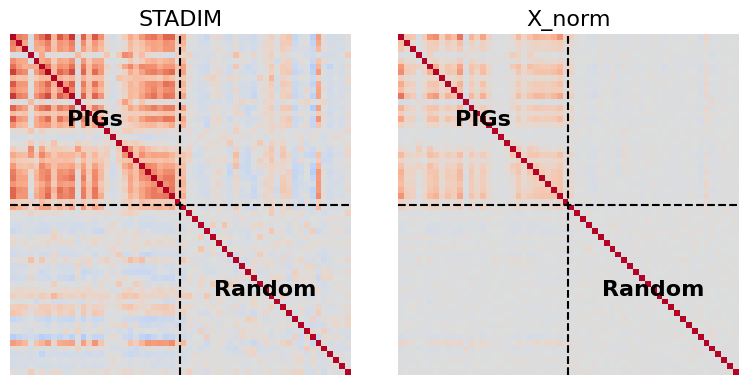

In [15]:
# 3. Focus on Disease Core Region
disease_mask = adata.obs['sample'].isin(['S5', 'S6', 'S7', 'S8'])
core_mask = disease_mask & (adata.obs['min_dist_to_plaque'] <= 150)
adata_core = adata[core_mask].copy()

# 4. Correlation Calculation & Heatmap Plotting
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
split_idx = len(valid_pigs)

for i, (method, layer) in enumerate(methods_map.items()):
    # Extract expression and compute Pearson correlation
    expr = adata_core.layers[layer]
    if hasattr(expr, "todense"): expr = expr.todense()
    df_corr = pd.DataFrame(np.asarray(expr)[:, [adata_core.var_names.get_loc(g) for g in all_genes]], columns=all_genes).corr()
    
    # Plotting
    ax = axes[i]
    sns.heatmap(df_corr, cmap='coolwarm', vmin=-1.0, vmax=1.0, square=True, cbar=False, 
                xticklabels=False, yticklabels=False, ax=ax)
    
    # Add quadrant separators
    ax.axhline(split_idx, color='black', lw=1.5, ls='--')
    ax.axvline(split_idx, color='black', lw=1.5, ls='--')
    ax.set_title(method, fontsize=16)
    
    # Simple Quadrant Labels
    ax.text(split_idx/2, split_idx/2, 'PIGs', ha='center', va='center', fontweight='bold')
    ax.text(split_idx*1.5, split_idx*1.5, 'Random', ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()